In [1]:
import sys
import pandas as pd
sys.path.append("../src")
from database import engine

In [2]:
query = """
SELECT
    d.timestamp,
    d.ontario_demand,

    MAX(CASE WHEN w.station = 'toronto'
        THEN w.temperature END) AS toronto_temp,

    MAX(CASE WHEN w.station = 'ottawa'
        THEN w.temperature END) AS ottawa_temp,

    MAX(CASE WHEN w.station = 'windsor'
        THEN w.temperature END) AS windsor_temp,

    MAX(CASE WHEN w.station = 'sudbury'
        THEN w.temperature END) AS sudbury_temp,

    MAX(CASE WHEN w.station = 'thunder_bay'
        THEN w.temperature END) AS thunder_bay_temp

FROM demand_hourly d
JOIN weather_hourly w
    ON d.timestamp = w.timestamp

GROUP BY
    d.timestamp,
    d.ontario_demand

ORDER BY d.timestamp;
"""

df = pd.read_sql(query, engine)
df.head()

,timestamp,ontario_demand,toronto_temp,ottawa_temp,windsor_temp,sudbury_temp,thunder_bay_temp
0,2025-01-01 00:00:00,13887,1.6,1.5,1.0,-1.2,-4.0
1,2025-01-01 01:00:00,13722,1.6,1.8,0.7,-1.4,-4.3
2,2025-01-01 02:00:00,13688,1.4,1.7,0.9,-1.5,-4.4
3,2025-01-01 03:00:00,13613,0.8,1.7,1.2,-1.6,-4.9
4,2025-01-01 04:00:00,13593,1.4,1.8,1.2,-1.7,-5.5


In [5]:
temperature_columns = [
    "toronto_temp",
    "ottawa_temp",
    "windsor_temp",
    "sudbury_temp",
    "thunder_bay_temp"
]

df["avg_temp"] = df[temperature_columns].mean(axis=1)

In [6]:
df[
    [
        "timestamp",
        "toronto_temp",
        "ottawa_temp",
        "windsor_temp",
        "sudbury_temp",
        "thunder_bay_temp",
        "avg_temp"
    ]
].head()

,timestamp,toronto_temp,ottawa_temp,windsor_temp,sudbury_temp,thunder_bay_temp,avg_temp
0,2025-01-01 00:00:00,1.6,1.5,1.0,-1.2,-4.0,-0.22
1,2025-01-01 01:00:00,1.6,1.8,0.7,-1.4,-4.3,-0.32
2,2025-01-01 02:00:00,1.4,1.7,0.9,-1.5,-4.4,-0.38
3,2025-01-01 03:00:00,0.8,1.7,1.2,-1.6,-4.9,-0.56
4,2025-01-01 04:00:00,1.4,1.8,1.2,-1.7,-5.5,-0.56


In [7]:
df["avg_temp_squared"] = df["avg_temp"] ** 2

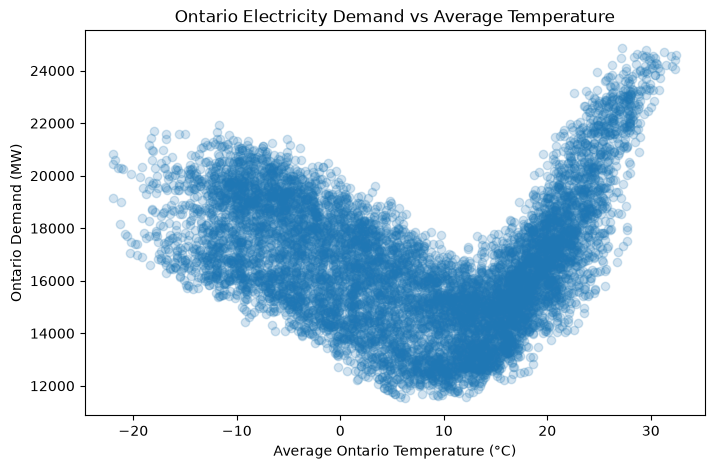

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["avg_temp"],
    df["ontario_demand"],
    alpha=0.2
)

plt.xlabel("Average Ontario Temperature (°C)")
plt.ylabel("Ontario Demand (MW)")
plt.title("Ontario Electricity Demand vs Average Temperature")
plt.show()

In [10]:
import numpy as np

df["hour"] = df["timestamp"].dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_of_week"] = df["timestamp"].dt.day_name()

day_columns = pd.get_dummies(
    df["day_of_week"],
    prefix="day",
    dtype=int,
    drop_first=True
)

df = pd.concat([df, day_columns], axis=1)
day_features = day_columns.columns.tolist()

weather_features = [
    "toronto_temp",
    "ottawa_temp",
    "windsor_temp",
    "sudbury_temp",
    "thunder_bay_temp"
]

In [13]:
X = df[
    ["hour_sin", "hour_cos"]
    + day_features
    + weather_features
    + ["avg_temp_squared"]
]

y = df["ontario_demand"]

In [14]:
X.columns.tolist()

['hour_sin',
 'hour_cos',
 'day_Monday',
 'day_Saturday',
 'day_Sunday',
 'day_Thursday',
 'day_Tuesday',
 'day_Wednesday',
 'toronto_temp',
 'ottawa_temp',
 'windsor_temp',
 'sudbury_temp',
 'thunder_bay_temp',
 'avg_temp_squared']

In [15]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-1250.92, -986.51, -84.51,..., -49.48, -36.59, 11.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['hour_sin','hour_cos','day_Monday',...,'sudbury_temp','thunder_bay_temp', 'avg_temp_squared']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.528e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [17]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 2157711.9477521256
RMSE: 1468.9152282388952
